In [ ]:
import yfinance as yf
D = yf.download(["^IXIC","^GSPC"], start="2023-01-01", end ="2026-04-05")
D = D.dropna()
E = D['Close']

/tmp/ipykernel_11154/3770446320.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  D = yf.download(["^IXIC","^GSPC"], start="2023-01-01", end ="2026-04-05")
[*********************100%***********************]  2 of 2 completed


In [ ]:
E = D['Close']['^IXIC']
H = D['Close']['^GSPC']
E.head()

,^IXIC
Date,
2023-01-03,10386.980469
2023-01-04,10458.759766
2023-01-05,10305.240234
2023-01-06,10569.290039
2023-01-09,10635.650391


In [ ]:
D.head()

Price             Close                       High                        Low  \
Ticker            ^GSPC         ^IXIC        ^GSPC         ^IXIC        ^GSPC   
Date                                                                            
2023-01-03  3824.139893  10386.980469  3878.459961  10613.059570  3794.330078   
2023-01-04  3852.969971  10458.759766  3873.159912  10515.219727  3815.770020   
2023-01-05  3808.100098  10305.240234  3839.739990  10393.219727  3802.419922   
2023-01-06  3895.080078  10569.290039  3906.189941  10604.139648  3809.560059   
2023-01-09  3892.090088  10635.650391  3950.570068  10807.259766  3890.419922   

Price                            Open                    Volume              
Ticker             ^IXIC        ^GSPC         ^IXIC       ^GSPC       ^IXIC  
Date                                                                         
2023-01-03  10309.160156  3853.290039  10562.059570  3959140000  4780650000  
2023-01-04  10337.639648  3840.360107  10467.820312  4414080000  5085380000  
2023-01-05  10295.250000  3839.739990  10390.309570  3893450000  4764270000  
2023-01-06  10265.040039  3823.370117  10363.959961  3923560000  5199780000  
2023-01-09  10619.120117  3910.820068  10662.099609  4311770000  5132190000

In [ ]:
import numpy as np
LE = np.log(E)
LE.head()

,^IXIC
Date,
2023-01-03,9.248308
2023-01-04,9.255195
2023-01-05,9.240408
2023-01-06,9.265708
2023-01-09,9.271967


In [ ]:
LH = np.log(H)
LH.head()

,^GSPC
Date,
2023-01-03,8.249089
2023-01-04,8.256600
2023-01-05,8.244886
2023-01-06,8.267470
2023-01-09,8.266702


In [ ]:
pip install arch

In [ ]:
#Prueba de Dickey Fuller ampliada ADF - SC, ST
from arch.unitroot import ADF
adf = ADF(LE, trend = 'n')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                  2.282
P-value                         0.996
Lags                                4
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE DICKEY FULLER AMPLIADA - CC, ST
from arch.unitroot import ADF
adf = ADF(LE, trend = 'c')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -1.923
P-value                         0.321
Lags                                4
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE DICKEY FULLER AMPLIADA ADF - CC,CT
from arch.unitroot import ADF
adf = ADF(LE, trend = 'ct')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.745
P-value                         0.218
Lags                                4
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.42 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS PERRON - SC,ST
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(LE, trend = 'n')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                  2.362
P-value                         0.997
Lags                               21
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS PERRON - CC,ST
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(LE, trend = 'c')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.016
P-value                         0.280
Lags                               21
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS - CC,CT
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(LE, trend = 'ct')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -3.223
P-value                         0.080
Lags                               21
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.42 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE KPSS - CC,ST
from arch.unitroot import KPSS
kpss = KPSS(LE, trend = 'c')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  4.116
P-value                         0.000
Lags                               18
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_11154/1252520515.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LE, trend = 'c')


In [ ]:
#PRUEBA DE KPSS - CC,CT
from arch.unitroot import KPSS
kpss = KPSS(LE, trend = 'ct')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  0.284
P-value                         0.002
Lags                               17
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_11154/107997315.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LE, trend = 'ct')


In [ ]:
#Prueba de Dickey Fuller ampliada ADF - SC, ST
from arch.unitroot import ADF
adf = ADF(LH, trend = 'n')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                  2.265
P-value                         0.996
Lags                                4
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE DICKEY FULLER AMPLIADA - CC, ST
from arch.unitroot import ADF
adf = ADF(LH, trend = 'c')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -1.431
P-value                         0.568
Lags                                4
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE DICKEY FULLER AMPLIADA ADF - CC,CT
from arch.unitroot import ADF
adf = ADF(LH, trend = 'ct')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.366
P-value                         0.398
Lags                                4
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.42 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS PERRON - SC,ST
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(LH, trend = 'n')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                  2.363
P-value                         0.997
Lags                               21
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS PERRON - CC,ST
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(LH, trend = 'c')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -1.514
P-value                         0.527
Lags                               21
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS - CC,CT
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(LH, trend = 'ct')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.886
P-value                         0.167
Lags                               21
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.42 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE KPSS - CC,ST
from arch.unitroot import KPSS
kpss = KPSS(LH, trend = 'c')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  4.179
P-value                         0.000
Lags                               18
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_11154/2346531266.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LH, trend = 'c')


In [ ]:
#PRUEBA DE KPSS - CC,CT
from arch.unitroot import KPSS
kpss = KPSS(LH, trend = 'ct')
print(kpss.summary().as_text())

/tmp/ipykernel_11154/2088747529.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(LH, trend = 'ct')


    KPSS Stationarity Test Results   
Test Statistic                  0.325
P-value                         0.001
Lags                               17
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


In [ ]:
DLE = LE.diff().dropna()
DLE.head()

,^IXIC
Date,
2023-01-04,0.006887
2023-01-05,-0.014787
2023-01-06,0.025300
2023-01-09,0.006259
2023-01-10,0.010008


In [ ]:
#PRUEBA DE DICKEY FULLER AMPLIADA ADF - SC,ST
from arch.unitroot import ADF
adf = ADF(DLE, trend = 'n')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                -15.634
P-value                         0.000
Lags                                3
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE DICKEY FULLER AMPLIADA ADF - CC,ST
from arch.unitroot import ADF
adf = ADF(DLE, trend = 'c')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                -15.849
P-value                         0.000
Lags                                3
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DICKEY FULLER - CC,CT
from arch.unitroot import ADF
adf = ADF(DLE, trend = 'ct')
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                -15.905
P-value                         0.000
Lags                                3
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.42 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS PERRON - SC,ST
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(DLE, trend = 'n')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -29.943
P-value                         0.000
Lags                               21
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA PHILLIPS PERRON - CC,ST
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(DLE, trend = 'c')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -30.327
P-value                         0.000
Lags                               21
-------------------------------------

Trend: Constant
Critical Values: -3.44 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE PHILLIPS PERRON - CC,CT
from arch.unitroot import PhillipsPerron
pp = PhillipsPerron(DLE, trend = 'ct')
print(pp.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -30.448
P-value                         0.000
Lags                               21
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: -3.97 (1%), -3.42 (5%), -3.13 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [ ]:
#PRUEBA DE KPSS - CC,ST
from arch.unitroot import KPSS
kpss = KPSS(DLE, trend = 'c')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  0.165
P-value                         0.347
Lags                               12
-------------------------------------

Trend: Constant
Critical Values: 0.74 (1%), 0.46 (5%), 0.35 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_11154/140757426.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(DLE, trend = 'c')


In [ ]:
#PRUEBA DE KPSS - CC,CT
from arch.unitroot import KPSS
kpss = KPSS(DLE, trend = 'ct')
print(kpss.summary().as_text())

    KPSS Stationarity Test Results   
Test Statistic                  0.037
P-value                         0.772
Lags                               12
-------------------------------------

Trend: Constant and Linear Time Trend
Critical Values: 0.22 (1%), 0.15 (5%), 0.12 (10%)
Null Hypothesis: The process is weakly stationary.
Alternative Hypothesis: The process contains a unit root.


/tmp/ipykernel_11154/3226283412.py:3: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss = KPSS(DLE, trend = 'ct')


In [ ]:
#PRUEBA DE COINTEGRACIÓN DE ENGLE-GRANGER SIN CONSTANTE SIN TENDENCIA.
from arch.unitroot import engle_granger
eg_test_SCST = engle_granger( LE, LH, trend = 'n')
print(eg_test_SCST)

Engle-Granger Cointegration Test
Statistic: -4.051070157396322
P-value: 0.0009033389711867079
Null: No Cointegration, Alternative: Cointegration
ADF Lag length: 0
Trend: c
Estimated Root ρ (γ+1): 0.9806690690487796
Distribution Order: 1


In [ ]:
from arch.unitroot import engle_granger
eg_test_CCST = engle_granger( LE, LH, trend = 'c')
eg_test_CCST

Test Statistic,-3.986
P-value,0.008
ADF Lag length,0
Estimated Root ρ (γ+1),0.975


In [ ]:
from arch.unitroot import engle_granger
eg_test_CCCT = engle_granger( LE, LH, trend = 'ct')
eg_test_CCCT

Test Statistic,-3.967
P-value,0.031
ADF Lag length,0
Estimated Root ρ (γ+1),0.976


In [ ]:
#PRUEBA DE COINTEGRACION DE PHILLIPS OULIARIS SIN CONSTANTE SIN TENDENCIA
from arch.unitroot.cointegration import phillips_ouliaris
po_zt_test_SCST = phillips_ouliaris( LE, LH, trend = 'n', test_type = "zt")
po_zt_test_SCST

Test Statistic,-4.057
P-value,0.001
Kernel,Bartlett
Bandwidth,5.759


In [ ]:
#PRUEBA DE COINTEGRACION DE PHILLIPS OULIARIS CON CONSTANTE SIN TENDENCIA
from arch.unitroot.cointegration import phillips_ouliaris
po_zt_test_CCST = phillips_ouliaris( LE, LH, trend = 'c', test_type = "zt")
po_zt_test_CCST

Test Statistic,-4.011
P-value,0.007
Kernel,Bartlett
Bandwidth,4.773


In [ ]:
#PRUEBA DE COINTEGRACION DE PHILLIPS OULIARIS CON CONSTANTE CON TENDENCIA
from arch.unitroot.cointegration import phillips_ouliaris
po_zt_test_CCCT = phillips_ouliaris( LE, LH, trend = 'ct', test_type = "zt")
po_zt_test_CCCT

Test Statistic,-4.004
P-value,0.028
Kernel,Bartlett
Bandwidth,5.414


In [ ]:
#REGAZO OPTIMO PARA PRUEBA DE JOHANSEN
from statsmodels.tsa.vector_ar.vecm import select_order
import pandas as pd

# Combine LE and LH into a single DataFrame
coi_data = pd.concat([LE, LH], axis=1)

RO = select_order(coi_data, maxlags=5, deterministic = "co")
print(RO.summary())

 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -20.67*     -20.62*  1.057e-09*     -20.65*
1      -20.66      -20.59   1.063e-09      -20.64
2      -20.65      -20.56   1.073e-09      -20.62
3      -20.66      -20.54   1.067e-09      -20.61
4      -20.65      -20.51   1.072e-09      -20.60
5      -20.65      -20.48   1.081e-09      -20.58
-------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
#PRUEBA DE COINTEGRACIÓN DE JOHANSEN
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [ ]:
from statsmodels.tsa.vector_ar.var_model import output
def jon_output(res):
  output = pd.DataFrame([res.lr2,res.lr1], index=["max_eig_stat","trace_stat"])
  print(output.T, "\n")
  print("valor critico (90%, 95%, 99%) de max_eig_stat Ho: r=0 Y Ho: r=1\n", res.cvm, "\n")
  print("valor critico (90%, 95%, 99%) de trace_stat Ho: r=0 Y Ho: r=1\n", res.cvt, "\n")

In [ ]:
# Función de cointegración (variables, 0:con constante, 2.rezago óptimo)
jon_model3 = coint_johansen(coi_data, 0, 1)
jon_output(jon_model3)

   max_eig_stat  trace_stat
0     20.426648   23.126964
1      2.700317    2.700317 

valor critico (90%, 95%, 99%) de max_eig_stat Ho: r=0 Y Ho: r=1
 [[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]] 

valor critico (90%, 95%, 99%) de trace_stat Ho: r=0 Y Ho: r=1
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]] 



In [ ]:
#SE CONFIGURA EL MODELO VEC
from statsmodels.tsa.vector_ar.vecm import VECM
modelVEC = VECM(coi_data, k_ar_diff=3, coint_rank=1 , deterministic='co')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
#SE OPERA EL MODELO VEC
resultadoVEC = modelVEC.fit()

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.api import VECM

In [ ]:
#IMPRIME TABLA DE RESULTADOS VEC
print (resultadoVEC.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation ^IXIC
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0122      0.012     -1.037      0.300      -0.035       0.011
L1.^IXIC      -0.1308      0.126     -1.040      0.298      -0.377       0.116
L1.^GSPC       0.1211      0.168      0.721      0.471      -0.208       0.450
L2.^IXIC       0.0172      0.126      0.137      0.891      -0.230       0.264
L2.^GSPC       0.0044      0.168      0.026      0.979      -0.325       0.334
L3.^IXIC       0.2116      0.126      1.682      0.093      -0.035       0.458
L3.^GSPC      -0.4138      0.168     -2.464      0.014      -0.743      -0.085
Det. terms outside the coint. relation & lagged endog. parameters for equation ^GSPC
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

In [ ]:
YT = (-0.0122 - 0.1388 + 0.1211 + 0.0172 + 0.0044 + 0.2116 - 0.4138)
XT = (0.0026 - 0.1114 + 0.1142 - 0.1766 + 0.0015 + 0.1608 - 0.3144)


In [ ]:
#RECUPERAR INNOVACION DEL MODELO VEC
INN_TOTAL_VECN = resultadoVEC.resid
INN_TOTAL_VEC = pd.DataFrame(INN_TOTAL_VECN, columns = ['^IXIC','^GSCP'])
INN_TOTAL_VEC.head()

,^IXIC,^GSCP
0,0.005526,0.000602
1,0.005578,0.005529
2,0.018748,0.015583
3,0.002224,0.002023
4,0.004945,0.004111


<Axes: >

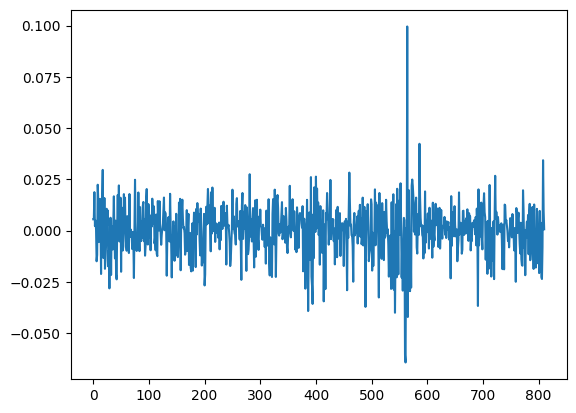

In [ ]:
#SELECCION DE LA INNOVACION DE BLOQUE DE ECUACIONES DE LA VARIABLE DE ANALISIS
INN_Y_VEC = INN_TOTAL_VEC['^IXIC']
INN_Y_VEC.plot()

In [ ]:
#PRUEBA DE AUTOCORRELACION VEC
sm.stats.acorr_ljungbox(INN_Y_VEC, lags=[3], return_df=True)

,lb_stat,lb_pvalue
3,0.102029,0.991593


In [ ]:
INN_Y2_VEC = INN_Y_VEC*INN_Y_VEC
sm.stats.acorr_ljungbox(INN_Y2_VEC, lags=[3], return_df=True)

,lb_stat,lb_pvalue
3,104.905648,1.369146e-22


In [ ]:
#IMPULSO RESPUESTA
from scipy.stats import normaltest
JB = normaltest(INN_Y_VEC)
JB

NormaltestResult(statistic=np.float64(116.32806774361354), pvalue=np.float64(5.491374266914025e-26))

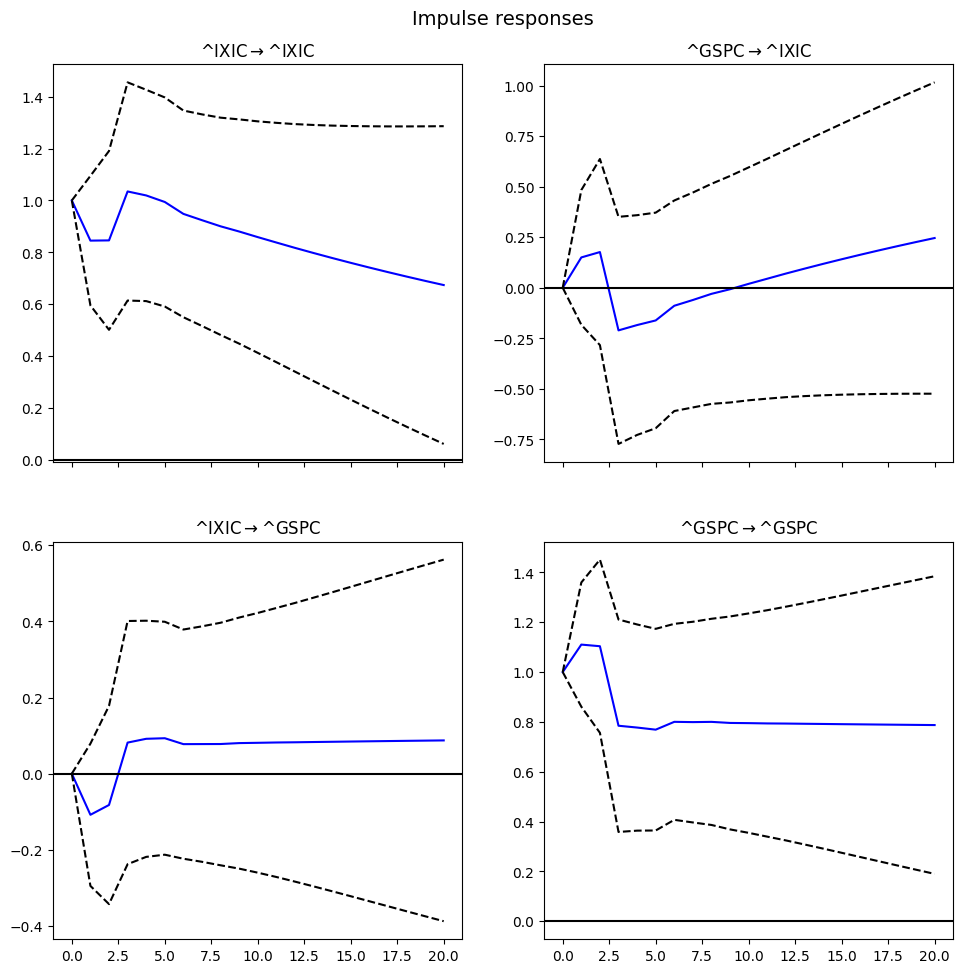

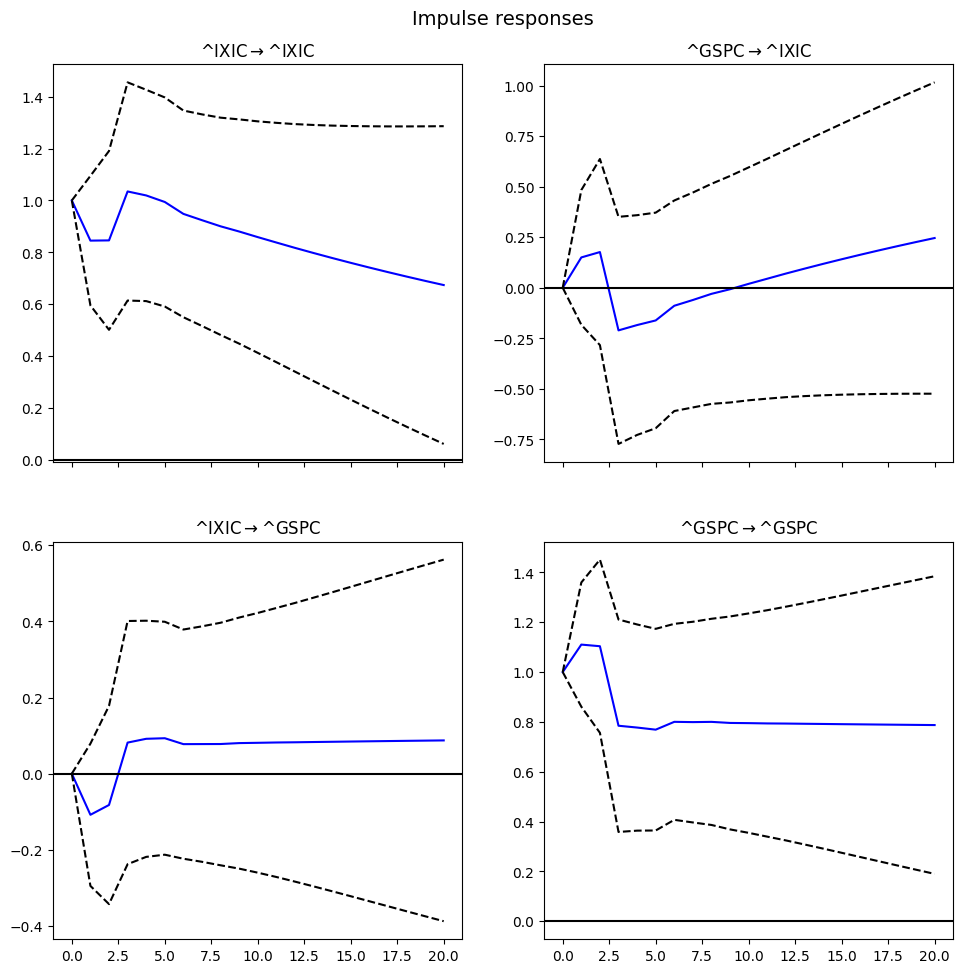

In [ ]:
irfVEC = resultadoVEC.irf(20)
irfVEC.plot (orth=False)